## Análise de hábitos e notas de estudantes
Notebook criado para realizar análises e previsões de notas emexames escolares com base em **hábitos** e **características** de estudantes.
- Bibliotecasutilizadas: Panda e Seaborn

### Realizar as importações das bibliotecas necessárias e, logo em seguida,atribui um nome para cada uma delas

In [2]:
import pandas as pd      # Para manipulação e análise de dados
import seaborn as sns    # Para visualizações estatísticas
import matplotlib.pyplot as plt # Para customização de gráficos
import numpy as np       # Para operações matemáticas (se necessário)

# Configuração opcional: melhora a estética dos gráficos
sns.set_theme(style="whitegrid")

### Criar uma "caixinha" DF ( Data Frame)

In [3]:
df = pd.read_csv(r".\Data\dataset_aula03_student_habits_performance.csv")

### Exibe as 5 primeiras linhas para conferir o carregamento
df.head()

In [4]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


### # Verifica as últimas 5 linhas do DataFrame
df.tail()

In [5]:
df.tail()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


### # Exibe as informações gerais do DataFrame, como tipos de dados e valores nulos
df.info()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

#Variável STR ou Object não é possivel criar gráficos


### Limpeza de Dados: Tratamento de valores ausentes

Para identificar a quantidade de registros sem informações na coluna de escolaridade dos pais, utilizei o comando abaixo:

`df["parental_education_level"].isna().sum()`

O resultado indicou a existência de **91** registros nulos, que foram posteriormente tratados utilizando o método `.fillna("Não informado")`.

In [7]:
df["parental_education_level"].isna().sum()

np.int64(91)

### Validação da Integridade dos Dados

Para garantir que a base de dados estava pronta para a análise, realizei a contagem de registros preenchidos na coluna de escolaridade dos pais:

`df["parental_education_level"].notnull().sum()`

Este comando confirmou que **909** linhas possuíam informações válidas, enquanto os **91** registros faltantes foram tratados para garantir a consistência das análises subsequentes.

In [8]:
df["parental_education_level"].notnull().sum()

np.int64(909)

### Tratamento de Dados Ausentes

Após identificar 91 registros sem informação na coluna `parental_education_level`, realizei o preenchimento desses dados com a categoria "Não informado":

```python
# Substituindo valores nulos para manter a integridade dos dados na análise
df["parental_education_level"] = df["parental_education_level"].fillna("Não informado")

In [9]:
df["parental_education_level"] = df["parental_education_level"].fillna("Não informado")


### Verificação da Limpeza dos Dados

Após tratar os valores ausentes, executei novamente o `df.info()` para confirmar a integridade da base de dados:

```python
# Confirmando que todos os 1000 registros estão preenchidos
df.info()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

### Explorando as Categorias dos Dados

Para entender a diversidade de informações na coluna `parental_education_level`, utilizei o método `unique()`:

```python
# Listando os valores distintos da escolaridade dos pais
df["parental_education_level"].unique()

In [11]:
df["parental_education_level"].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Não informado']
Length: 4, dtype: str

### Contagem de Categorias

Para validar a estrutura da coluna `parental_education_level`, verifiquei a quantidade total de níveis de escolaridade existentes:

```python
# Verificando a quantidade de níveis distintos
df["parental_education_level"].nunique()

In [12]:
df["parental_education_level"].nunique()

4

### Criar colunas

### Seleção de Variáveis Numéricas

Para realizar a análise de correlação entre os hábitos dos alunos e suas respectivas notas, criei uma lista contendo apenas as variáveis quantitativas do dataset:

```python
# Lista de colunas numéricas para análise estatística
colunas = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours", 
           "attendance_percentage", "sleep_hours", "exercise_frequency", 
           "mental_health_rating", "exam_score"]

In [13]:
colunas = ["age","study_hours_per_day","social_media_hours","netflix_hours","attendance_percentage","sleep_hours", "exercise_frequency","mental_health_rating","exam_score"]

### Análise de Correlação (Mapa de Calor)

Para identificar quais hábitos possuem maior impacto no desempenho acadêmico, gerei um mapa de calor das correlações entre as variáveis numéricas:

```python
# Gerando o mapa de calor para visualizar correlações
sns.heatmap(data=df[colunas].corr(), annot=True, cmap="coolwarm", fmt=".2f");

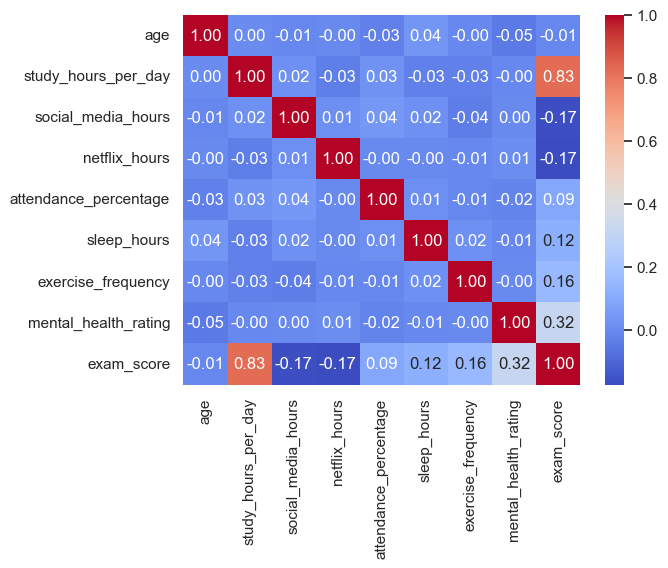

In [14]:
sns.heatmap(data=df[colunas].corr(), annot=True, cmap="coolwarm",fmt=".2f");

### Análise de Correlação: Horas de Estudo vs. Nota no Exame

Para entender o impacto das horas de estudo no desempenho dos alunos, foi plotado um gráfico de dispersão com uma linha de regressão linear utilizando a biblioteca Seaborn.

```python
sns.lmplot(data=df, x="study_hours_per_day", y="exam_score")

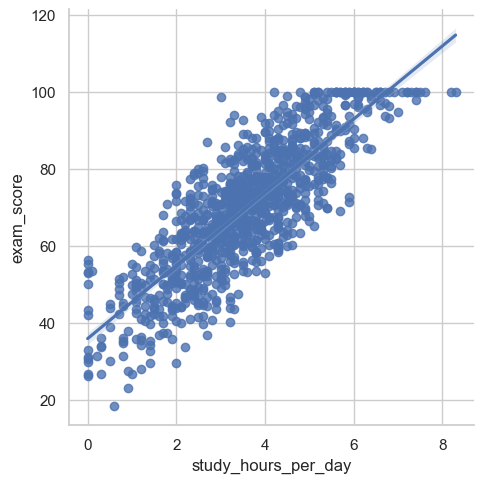

In [15]:
sns.lmplot(data=df, x="study_hours_per_day", y="exam_score")